<a href="https://colab.research.google.com/github/sanjanapatilvv5/NNDL-Lab/blob/main/NNDL_EXP_14_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.4994 | G Loss: 0.6507
Epoch 200 | D Loss: 5.5400 | G Loss: 0.0061
Epoch 400 | D Loss: 5.7575 | G Loss: 0.0031
Epoch 600 | D Loss: 5.8828 | G Loss: 0.0021
Epoch 800 | D Loss: 5.9807 | G Loss: 0.0016
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


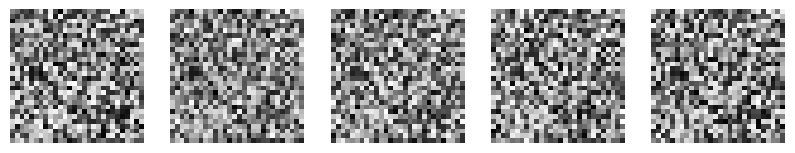

In [1]:
#EXP-14..................
# Install libraries
!pip install tensorflow matplotlib

# Imports
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess dataset
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = np.reshape(x_train, (x_train.shape[0], 784))

# Generator
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=100),
        layers.Dense(784, activation='tanh')
    ])
    return model

# Discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=784),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Build models
generator = build_generator()
discriminator = build_discriminator()

# Compile discriminator
discriminator.compile(optimizer='adam', loss='binary_crossentropy')

# GAN (generator + frozen discriminator)
discriminator.trainable = False
gan = tf.keras.Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')

# Training loop
epochs = 1000
batch_size = 128

for epoch in range(epochs):
    # Train discriminator
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_images = x_train[idx]

    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_images = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_images, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_images, np.zeros((batch_size, 1)))

    # Train generator
    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    # Print progress
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {0.5*(d_loss_real + d_loss_fake):.4f} | G Loss: {g_loss:.4f}")

# Generate and display images
noise = np.random.normal(0, 1, (5, 100))
gen_images = generator.predict(noise)

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(gen_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()